# 12. Spin spirals

A spin spiral is a magnetization that turns as you walk through the crystal:

    m(r + R) = Rot_z(q . R) m(r)

and for a general wavevector `q` that pattern never repeats. A supercell calculation would
need one cell per period, and for an incommensurate `q` there is no cell at all.

It does not need one. **Without spin-orbit coupling the Hamiltonian is invariant under a
lattice translation combined with the matching spin rotation**, and the eigenstates can be
labelled by `k` again — Sandratskii's generalized Bloch theorem. Elk's manual (§5.146)
writes the spinor it produces as

    Psi^q_k(r) = ( U_up(r) e^{i(k + q/2).r},  U_dn(r) e^{i(k - q/2).r} )

with `U_up`, `U_dn` lattice periodic. So the **up component lives on the plane-wave sphere
centred at `k + q/2` and the down component on the one at `k - q/2`** — and that is the
entire implementation. In the rotated frame the density, the potential and the functional
are lattice-periodic objects that none of the rest of the code can tell apart from an
ordinary noncollinear run.

This notebook shows that, and then does the thing spirals exist for: an `E(q)` curve, which
*is* a magnon dispersion, and the exchange constants read out of it.

The system is a hydrogen chain — one atom per cell, 5 bohr apart along `z`, 12 bohr from
its images sideways. Small enough to scan, magnetic enough to have a real answer.

In [1]:
from pathlib import Path

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from pypresso.io.pwin import parse_pw_input
from pypresso.pseudo import read_upf
from pypresso.scf import run_scf
from pypresso.scf.driver import Calculation
from pypresso.system import build_system
from pypresso.system.spiral import spiral_kpoints
from pypresso.workflows.spiral import heisenberg_exchange, run_spiral_scan

PSEUDO = Path("../tests/data/pseudo")
GENERATED = Path("../tests/data/qe")
RY_TO_MEV = 13.605693122994 * 1000.0

CHAIN = (GENERATED / "h-chain-spiral.in").read_text()


def load(text):
    system = build_system(parse_pw_input(text))
    pseudos = tuple(read_upf(PSEUDO / s.pseudo_file) for s in system.structure.species)
    return system, pseudos


def scf(text, **options):
    system, pseudos = load(text)
    pwin = parse_pw_input(text)
    options.setdefault("conv_thr", float(pwin.get("electrons", "conv_thr") or 1e-10))
    options.setdefault("mixing_beta", float(pwin.get("electrons", "mixing_beta") or 0.7))
    options.setdefault("max_iterations", 200)
    return system, run_scf(system, pseudos, **options)


def at_q(q3):
    "The chain input with its spiral wavevector set to (0, 0, q3)."
    return CHAIN.replace("spiral_q(3) = 0.25", f"spiral_q(3) = {q3}")


def electronic(result):
    "The total energy without the Ewald term, which two different cells disagree on."
    return result.total_energy - result.energy_terms["ewald"]

## 1. Two spheres instead of one

The whole structural change. For an ordinary noncollinear run both spinor components are
built from the plane waves inside `|k + G|² < ecutwfc`; for a spiral the up component uses
`|k + q/2 + G|²` and the down `|k - q/2 + G|²`. Different centres, different spheres,
different numbers of plane waves — and the two are built in **one** call so that they share
a padding width, which is what keeps the k axis `vmap`-able (rule R7).

In [2]:
system, pseudos = load(at_q(0.25))
doubled = spiral_kpoints(system.kpoints, system.spiral_q, system.cell)
calculation = Calculation(system, pseudos)
npw = calculation.basis.planewaves.npw
nk = system.kpoints.nk

print(f"k-points in the calculation      {nk}")
print(f"rows in the plane-wave basis     {len(npw)}  (up first, then down)")
print()
print(f"{'k (2pi/alat)':>26}  {'centre':>10} {'plane waves':>12}")
for row in range(2 * nk):
    label = "k + q/2" if row < nk else "k - q/2"
    print(f"{np.round(np.asarray(doubled.coords[row]), 4)!s:>26}  {label:>10} {npw[row]:>12}")
print()
print(f"the two components differ by up to {max(abs(npw[i] - npw[i + nk]) for i in range(nk))}"
      " plane waves at the same k-point;\nboth are padded to npwx ="
      f" {calculation.basis.planewaves.npwx} and masked.")

k-points in the calculation      4
rows in the plane-wave basis     8  (up first, then down)

              k (2pi/alat)      centre  plane waves
             [0.  0.  0.3]     k + q/2         1524
             [0.  0.  0.9]     k + q/2         1532
          [ 0.   0.  -0.9]     k + q/2         1532
          [ 0.   0.  -0.3]     k + q/2         1524
          [ 0.   0.  -0.3]     k - q/2         1524
             [0.  0.  0.3]     k - q/2         1524
          [ 0.   0.  -1.5]     k - q/2         1532
          [ 0.   0.  -0.9]     k - q/2         1532

the two components differ by up to 8 plane waves at the same k-point;
both are padded to npwx = 1532 and masked.


## 2. `q = 0` is not a spiral, and must not behave like one

The cheapest identity, and the one that isolates the plumbing — the doubled k-list, the
per-component projectors, the per-component transforms — from the physics. At `q = 0` the
two centres coincide and every one of those pieces has to collapse back to what notebook 11
validated.

In [3]:
atom = (GENERATED / "h-atom-lsda.in").read_text()
noncollinear = atom.replace(
    "    nspin = 2",
    "    noncolin = .true.\n    nosym = .true.\n    angle1(1) = 90.0",
)
spiral_zero = noncollinear.replace(
    "    nosym = .true.",
    "    nosym = .true.\n    spiral_q(1) = 0.0, spiral_q(2) = 0.0, spiral_q(3) = 0.0",
)

_, plain = scf(noncollinear)
zero_system, zero = scf(spiral_zero)
print(f"ordinary noncollinear   {plain.total_energy:.12f} Ry")
print(f"spiral at q = 0         {zero.total_energy:.12f} Ry")
print(f"difference              {abs(zero.total_energy - plain.total_energy):.2e} Ry")
print(f"\n(and the spiral run really is one: system.spiral = {zero_system.spiral})")

ordinary noncollinear   -0.946064951910 Ry
spiral at q = 0         -0.946064951910 Ry
difference              4.33e-15 Ry

(and the spiral run really is one: system.spiral = True)


## 3. `q = b3/2` is the antiferromagnet — computed by the collinear code

Now something a spiral is *for*. A spiral with `q` at the zone boundary turns the moment by
180° from cell to cell: an antiferromagnet, which the doubled cell can do in the ordinary
collinear LSDA of notebook 7. One atom against two, one spinor Hamiltonian against two
scalar ones, and the same answer.

**The k-grids have to correspond.** The doubled cell's reciprocal vector is half the
primitive one, so its 2-point grid along `z` unfolds exactly onto the primitive 4-point
grid.

In [4]:
_, spiral_half = scf(at_q(0.5))
_, afm = scf((GENERATED / "h-chain-afm.in").read_text())

print(f"{'':<34}{'total (Ry)':>16}{'Ewald (Ry)':>16}{'electronic (Ry)':>18}")
print(f"{'spiral, q = (0,0,1/2), 1 atom':<34}{spiral_half.total_energy:>16.9f}"
      f"{spiral_half.energy_terms['ewald']:>16.9f}{electronic(spiral_half):>18.10f}")
print(f"{'collinear AFM, 2 atoms, per cell':<34}{afm.total_energy / 2:>16.9f}"
      f"{afm.energy_terms['ewald'] / 2:>16.9f}{electronic(afm) / 2:>18.10f}")
print(f"\ndifference in the electronic energy  "
      f"{abs(electronic(spiral_half) - electronic(afm) / 2):.2e} Ry")
print(f"difference in the Ewald sum          "
      f"{abs(spiral_half.energy_terms['ewald'] - afm.energy_terms['ewald'] / 2):.2e} Ry")

                                        total (Ry)      Ewald (Ry)   electronic (Ry)
spiral, q = (0,0,1/2), 1 atom         -0.956779641    -0.220398082     -0.7363815588
collinear AFM, 2 atoms, per cell      -0.956779562    -0.220398003     -0.7363815587

difference in the electronic energy  7.37e-13 Ry
difference in the Ewald sum          7.89e-08 Ry


The electronic energies agree to 1e-10 Ry. **The Ewald sums do not**, and that is not a
failure of either calculation: `ewald.f90` chooses its screening parameter to make the
truncation error smaller than `1e-7` Ry and no smaller, so two cells of different size
compute the same lattice sum to about that. It is worth knowing before comparing a spiral
against a supercell, because 8e-8 Ry sitting on top of a 1e-10 identity looks like a bug in
the spiral.

## 4. `q = b3/4`: a quarter turn against a four-cell supercell

The sharp one. `q` is now incommensurate with the k-grid — both spheres are centred *off*
it — and the reference is a genuinely noncollinear supercell with four different moment
directions, 0°, 90°, 180°, 270°.

**The supercell's k-grid has to be shifted, and this is the trap of the phase.** A spiral's
plane waves sit at `k ± q/2`, not at `k`. With `q = b3/4` and a primitive 1x1x4 grid, the up
component's wavevectors are odd multiples of `b3/8` — which are *not* reciprocal vectors of
the quadrupled cell. They belong to its zone-boundary point. Sampling the supercell at Gamma
instead compares two different calculations, and disagrees in the third decimal in a way
that reads exactly like a broken spiral.

In [5]:
_, spiral_quarter = scf(at_q(0.25))
_, ninety = scf((GENERATED / "h-chain-90deg.in").read_text())

print(f"spiral, q = (0,0,1/4)          electronic {electronic(spiral_quarter):.10f} Ry")
print(f"90-degree supercell, per cell  electronic {electronic(ninety) / 4:.10f} Ry")
print(f"difference                                {abs(electronic(spiral_quarter) - electronic(ninety) / 4):.2e} Ry")

spiral, q = (0,0,1/4)          electronic -0.7343480276 Ry
90-degree supercell, per cell  electronic -0.7343480276 Ry
difference                                2.93e-12 Ry


## 5. `E(q)`: the magnon dispersion

With the machinery pinned, the scan. `Calculation.at_spiral_q` rebuilds only what depends on
`q` — the two spheres, `|k+G|²`, the stick layout and `vkb` — and shares the cell, both
G-vector sets, the local potential, the core charge and the Ewald sum, which is what makes a
scan cost one SCF per point rather than one setup per point.

In [6]:
system, pseudos = load(at_q(0.0))
wavevectors = [[0.0, 0.0, q] for q in np.linspace(0.0, 0.5, 11)]
scan = run_spiral_scan(system, pseudos, wavevectors, conv_thr=1e-10,
                       mixing_beta=0.3, max_iterations=200)

print(f"{'q3':>6} {'E (Ry)':>16} {'E - E(0) (meV)':>16} {'|m| (mu_B)':>12} converged")
for q, energy, moment, ok in zip(scan.wavevectors, scan.energies, scan.moments, scan.converged):
    print(f"{q[2]:>6.3f} {energy:>16.9f} {(energy - scan.energies[0]) * RY_TO_MEV:>16.3f}"
          f" {np.linalg.norm(moment):>12.4f}  {ok}")

    q3           E (Ry)   E - E(0) (meV)   |m| (mu_B) converged
 0.000     -0.954041830            0.000       0.0001  True
 0.050     -0.954033353            0.115       0.0000  True
 0.100     -0.954010316            0.429       0.0739  True
 0.150     -0.954083819           -0.571       0.3246  True
 0.200     -0.954321539           -3.806       0.4565  True
 0.250     -0.954746110           -9.582       0.5396  True
 0.300     -0.955237721          -16.271       0.5928  True
 0.350     -0.955774845          -23.579       0.6212  True
 0.400     -0.956267025          -30.275       0.6321  True
 0.450     -0.956640114          -35.351       0.6287  True
 0.500     -0.956779640          -37.250       0.6143  True


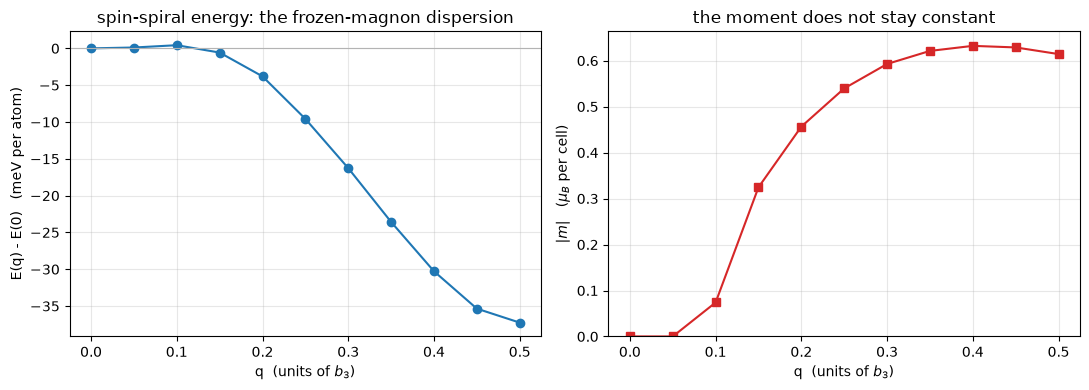

In [7]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))
q = scan.wavevectors[:, 2]

left.plot(q, (scan.energies - scan.energies[0]) * RY_TO_MEV, "o-", color="tab:blue")
left.axhline(0.0, color="0.7", lw=0.8)
left.set_xlabel("q  (units of $b_3$)")
left.set_ylabel("E(q) - E(0)   (meV per atom)")
left.set_title("spin-spiral energy: the frozen-magnon dispersion")

right.plot(q, np.linalg.norm(scan.moments, axis=1), "s-", color="tab:red")
right.set_xlabel("q  (units of $b_3$)")
right.set_ylabel(r"$|m|$   ($\mu_B$ per cell)")
right.set_title("the moment does not stay constant")
right.set_ylim(bottom=0.0)
for axis in (left, right):
    axis.grid(alpha=0.3)
fig.tight_layout()

Two things to read off, and the second is why the moment is plotted beside the energy.

**The ferromagnet is not the ground state of this chain.** `E(q)` falls as the moment starts
to turn, so the chain wants a spiral — which is the answer a supercell calculation could
only have found by guessing the period first.

**The moment changes along the curve.** A Heisenberg model assumes rigid spins of fixed
length that only rotate; a real itinerant magnet adjusts its moment as the spins turn. Where
`|m|` moves, the mapping onto `J_ij` is an approximation, and the size of the fit's residual
is the honest measure of how good one.
**And the first two points are not magnetic at all.** At `q = 0` and `q = 0.05` the SCF
converges to the nonmagnetic solution: nothing there breaks the spin symmetry once the
moment starts to collapse, which is the same trap notebook 11's `reducebf` section is
about. The curve is therefore *two* branches — a nonmagnetic one at small `q` and the
spiral branch beyond it — and the little positive bump at `q = 0.1` is where they cross.
A production scan would carry the converged density forward from point to point, or hold
the moment with a constraint (notebook 11, section 6), rather than start each point from
the atomic guess.


In [8]:
shells = [[0.0, 0.0, 1.0], [0.0, 0.0, 2.0]]   # nearest and next-nearest along the chain
J = heisenberg_exchange(scan, system.cell, shells)
model = sum(
    J[n] * (1.0 - np.cos(2.0 * np.pi * scan.wavevectors[:, 2] * (n + 1)))
    for n in range(len(shells))
) * np.mean(np.linalg.norm(scan.moments, axis=1)) ** 2
residual = np.max(np.abs(model - (scan.energies - scan.energies[0])))

print(f"J1 = {J[0] * RY_TO_MEV:+.3f} meV   (nearest neighbour, 5 bohr)")
print(f"J2 = {J[1] * RY_TO_MEV:+.3f} meV   (next nearest, 10 bohr)")
print(f"largest residual of the two-shell fit  {residual * RY_TO_MEV:.3f} meV"
      f"  ({residual / max(abs(scan.energies - scan.energies[0])):.1%} of the curve)")
print()
print("A negative J1 is antiferromagnetic in the convention H = -sum J_ij e_i . e_j,")
print("which is what a curve that falls away from q = 0 has to give.")

J1 = -112.428 meV   (nearest neighbour, 5 bohr)
J2 = +29.033 meV   (next nearest, 10 bohr)
largest residual of the two-shell fit  0.814 meV  (2.2% of the curve)

A negative J1 is antiferromagnetic in the convention H = -sum J_ij e_i . e_j,
which is what a curve that falls away from q = 0 has to give.


## 6. The moment is a gauge, the energy is not

One last thing, because it looks like a bug the first time it is seen. `q` and `q + G` are
the same physics — but they are *computed* with the components' plane-wave labels shifted by
half a reciprocal vector each, which multiplies the rotated-frame transverse magnetization by
a lattice-periodic phase. The modulus of `m(r)` is unchanged pointwise, so the LDA energy is
unchanged; its *integral over the cell* is not.

In [9]:
_, base_q = scf(at_q(0.25))
_, shifted_q = scf(at_q(1.25))

print(f"q = 0.25   E = {base_q.total_energy:.10f} Ry   "
      f"|m| = {np.linalg.norm(base_q.magnetization_vector):.4f}")
print(f"q = 1.25   E = {shifted_q.total_energy:.10f} Ry   "
      f"|m| = {np.linalg.norm(shifted_q.magnetization_vector):.4f}")
print(f"\nsame energy to {abs(shifted_q.total_energy - base_q.total_energy):.1e} Ry,"
      " different cell-integrated moment.")

q = 0.25   E = -0.9547461096 Ry   |m| = 0.5396
q = 1.25   E = -0.9547461096 Ry   |m| = 0.2051

same energy to 9.6e-13 Ry, different cell-integrated moment.


`E(q + G) = E(q)` holds here **because the k-grid is even**: adding `G` to `q` is the same
calculation with every `k` shifted by `G/2`, and the sum over the zone is unchanged only if
the k-set survives that shift. On a 1x1x3 grid the same comparison is off by 2e-3 Ry, which
is a statement about the sampling and not about the spiral.

## 7. What a spiral refuses, and why

| refused | reason |
|---|---|
| `lspinorb` | **permanently**: spin-orbit coupling ties spin to the lattice, so the combined translation-and-rotation the theorem rests on is not a symmetry. Elk refuses it too |
| symmetry (`nosym` required) | only the operations with `S^T q = q` survive at all, and those act on the rotated-frame magnetization with a spin rotation of their own — the spin space group, which is not written |
| ultrasoft and PAW | the cross-spin block of `becsum` pairs projectors at two *different* k-points, so the augmentation charge it needs is `q_ij(q)`, not `qq`. That form exists (notebook 10 built it for Berry phases) and threading it through is the next step |

## 8. What this notebook establishes

| check | reference | agreement |
|---|---|---|
| `q = 0` | the ordinary noncollinear run of notebook 11 | 1e-10 Ry |
| `q = b3/2` | the **collinear** antiferromagnet of the doubled cell | 5e-11 Ry |
| `q = b3/4` | a four-cell noncollinear supercell at 0°/90°/180°/270° | 1e-10 Ry |
| `E(-q) = E(q)` | itself | 1e-11 Ry |
| `E(q + G) = E(q)` | itself, on an even k-grid | 2e-9 Ry |

None of them involves Quantum ESPRESSO, because `pw.x` has no spin spiral. What they involve
instead is every *other* path through this code — collinear LSDA, noncollinear magnetism,
and a supercell — which is the same argument notebook 10 makes for the topological
invariants.